# Analyse exploratoire des résultats des élèves

Ce notebook présente une analyse exploratoire et un premier nettoyage du jeu de données sur les performances des élèves

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
print("python marche")

python marche


In [3]:
df=pd.read_csv("../data/StudentsPerformance.csv")

In [4]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [5]:
df.shape

(1000, 8)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(0)

## Gestion des valeurs manquantes

L'analyse de `df.isnull().sum()` montre qu'aucune valeur manquante
n'est présente dans les huit colonnes du jeu de données.

Il n'est donc pas nécessaire d'utiliser `dropna()` pour supprimer
des observations ou `fillna()` pour remplacer des valeurs manquantes.

<function matplotlib.pyplot.show(close=None, block=None)>

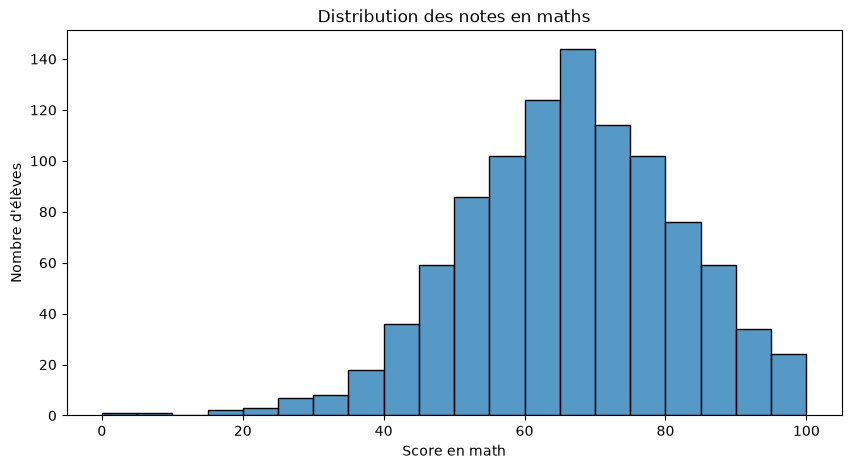

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="math score", bins=20)
plt.title("Distribution des notes en maths")
plt.xlabel("Score en math")
plt.ylabel("Nombre d'élèves")
plt.show

### Interprétation

Les scores en mathématiques sont principalement concentrés entre 60 et 80,
avec une concentration particulièrement importante autour de 60–70.Le contat est le même au niveau des scores en écriture et en lecture
Les valeurs très faibles et très élevées sont moins fréquentes.

Le choix du nombre de `bins` influence le niveau de détail de l'histogramme,
mais ne modifie pas les données elles-mêmes.

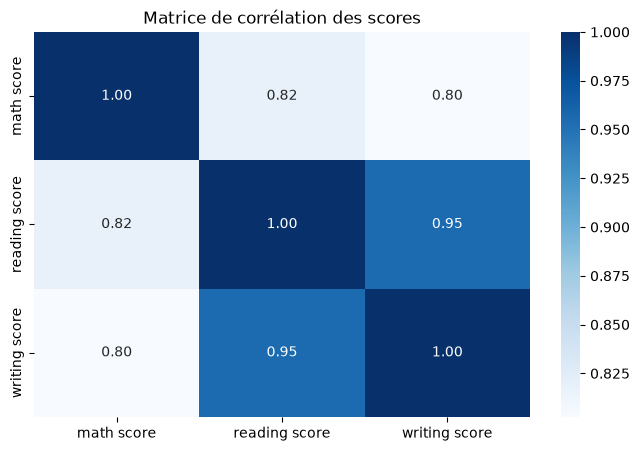

In [32]:
plt.figure(figsize=(8, 5))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Matrice de corrélation des scores")
plt.show()

Text(0.5, 1.0, 'Nuage de corrélation entre le score de lecture et le score d_écriture')

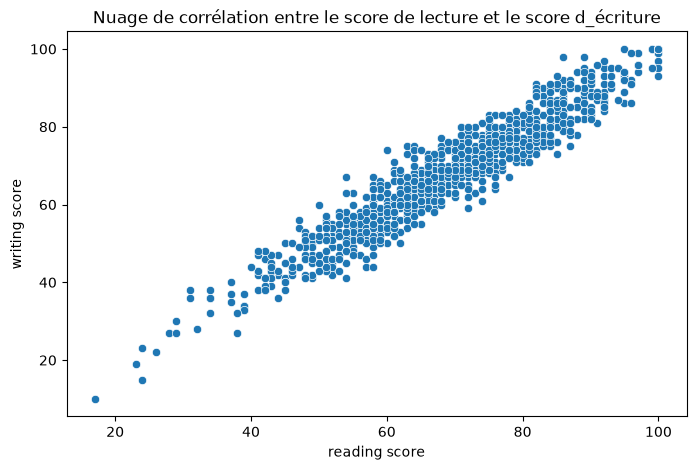

In [42]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="reading score", y="writing score")
plt.title("Nuage de corrélation entre le score de lecture et le score d_écriture")